# What Wins NBA Games? A Look at 26,000+ Games (2004-2020)

This notebook explores NBA game data to figure out which stats actually matter when it comes to winning. I'm working with five datasets covering games, player details, team info, and rankings across 17 seasons.

The main question: what separates winning teams from losing teams, and how big of a deal is home court advantage really?

In [1]:
import pandas as pd
import sqlite3
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# load all 5 CSV files from the nba_data folder
data_path = os.path.join(os.path.expanduser('~'), 'nba_data')

games = pd.read_csv(os.path.join(data_path, 'games.csv'))
games_details = pd.read_csv(os.path.join(data_path, 'games_details.csv'))
players = pd.read_csv(os.path.join(data_path, 'players.csv'))
ranking = pd.read_csv(os.path.join(data_path, 'ranking.csv'))
teams = pd.read_csv(os.path.join(data_path, 'teams.csv'))

print('games:', games.shape)
print('games_details:', games_details.shape)
print('players:', players.shape)
print('ranking:', ranking.shape)
print('teams:', teams.shape)

games: (26651, 21)
games_details: (668628, 29)
players: (7228, 4)
ranking: (210342, 13)
teams: (30, 14)


In [2]:
# create a SQLite database so we can run SQL queries on the data
conn = sqlite3.connect('nba.db')

games.to_sql('games', conn, if_exists='replace', index=False)
games_details.to_sql('games_details', conn, if_exists='replace', index=False)
players.to_sql('players', conn, if_exists='replace', index=False)
ranking.to_sql('ranking', conn, if_exists='replace', index=False)
teams.to_sql('teams', conn, if_exists='replace', index=False)

print('All tables loaded into nba.db!')

# verify tables
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print('Tables:', [row[0] for row in cursor.fetchall()])

All tables loaded into nba.db!
Tables: ['games', 'games_details', 'players', 'ranking', 'teams']


In [3]:
# helper function to run SQL queries easily
def query(sql):
    return pd.read_sql_query(sql, conn)

# filter out rows with missing data and build some useful columns
games = pd.read_sql_query(
    "SELECT * FROM games WHERE HOME_TEAM_WINS IS NOT NULL AND PTS_home IS NOT NULL", conn
)
teams_df = pd.read_sql_query("SELECT TEAM_ID, NICKNAME, ABBREVIATION FROM teams", conn)

# create stat differentials (home minus away)
games['SCORE_DIFF'] = games['PTS_home'] - games['PTS_away']
games['FG_PCT_DIFF'] = games['FG_PCT_home'] - games['FG_PCT_away']
games['FG3_PCT_DIFF'] = games['FG3_PCT_home'] - games['FG3_PCT_away']
games['AST_DIFF'] = games['AST_home'] - games['AST_away']
games['REB_DIFF'] = games['REB_home'] - games['REB_away']

home_win_rate = games['HOME_TEAM_WINS'].mean()

# pull season year from the game date
games['GAME_DATE_EST'] = pd.to_datetime(games['GAME_DATE_EST'])
games['SEASON'] = games['GAME_DATE_EST'].apply(lambda x: x.year if x.month >= 10 else x.year - 1)

os.makedirs('charts', exist_ok=True)

print(f'Total games after cleaning: {len(games)}')
print(f'Overall home win rate: {home_win_rate:.3f}')

Total games after cleaning: 26552
Overall home win rate: 0.589


## Data Cleansing

Before jumping into the analysis, I needed to clean up the data a bit. Here's what I did:

- Removed rows where HOME_TEAM_WINS was null since those games don't have a recorded outcome
- Dropped rows with missing PTS_home values because we can't analyze scoring without scores
- Converted GAME_DATE_EST to a proper datetime format so I could group games by season
- Created a SEASON column by checking if the game month was October or later (start of NBA season) or before October (still the previous season)
- Built differential columns (home minus away) for FG%, 3PT%, assists, and rebounds to make comparisons easier

The original games dataset had 26,651 rows. After cleaning, we're working with 26,552 games. Not a huge drop, but the removed rows would have caused problems in the analysis.

In [4]:
# quick check on what we cleaned up
print('Original games rows:', 26651)
print('Cleaned games rows:', len(games))
print('Rows removed:', 26651 - len(games))
print()

# check for any remaining nulls in key columns
key_cols = ['PTS_home', 'PTS_away', 'FG_PCT_home', 'FG_PCT_away', 'AST_home', 'REB_home', 'HOME_TEAM_WINS']
print('Null counts in key columns:')
print(games[key_cols].isnull().sum())

Original games rows: 26651
Cleaned games rows: 26552
Rows removed: 99

Null counts in key columns:
PTS_home          0
PTS_away          0
FG_PCT_home       0
FG_PCT_away       0
AST_home          0
REB_home          0
HOME_TEAM_WINS    0
dtype: int64


## Issues Being Analyzed

Here are the main questions I want to answer with this data:

1. Is home court advantage real, and has it changed over the years?
2. Which game stats have the strongest connection to winning?
3. How do offensive stats (points, assists, rebounds) differ between winning and losing teams?
4. Does shooting efficiency (FG%) predict wins at the team level too, not just game by game?
5. What does the "profile" of a winning game look like vs a losing game when you compare all the key stats side by side?

## The Big Picture: Correlation Heatmap

Before getting into specific topics, let's see how every major stat relates to home team wins. The heatmap below shows correlation coefficients between all the key stats. Positive values mean the stat goes up when the home team wins, negative means it goes down.

Some things that stood out to me right away: FG% has the strongest single connection to winning at r=0.43, and the away team's FG% is the strongest negative predictor at r=-0.44 (which makes sense, if the other team is shooting well you're probably losing). Free throw percentage barely registers at all.

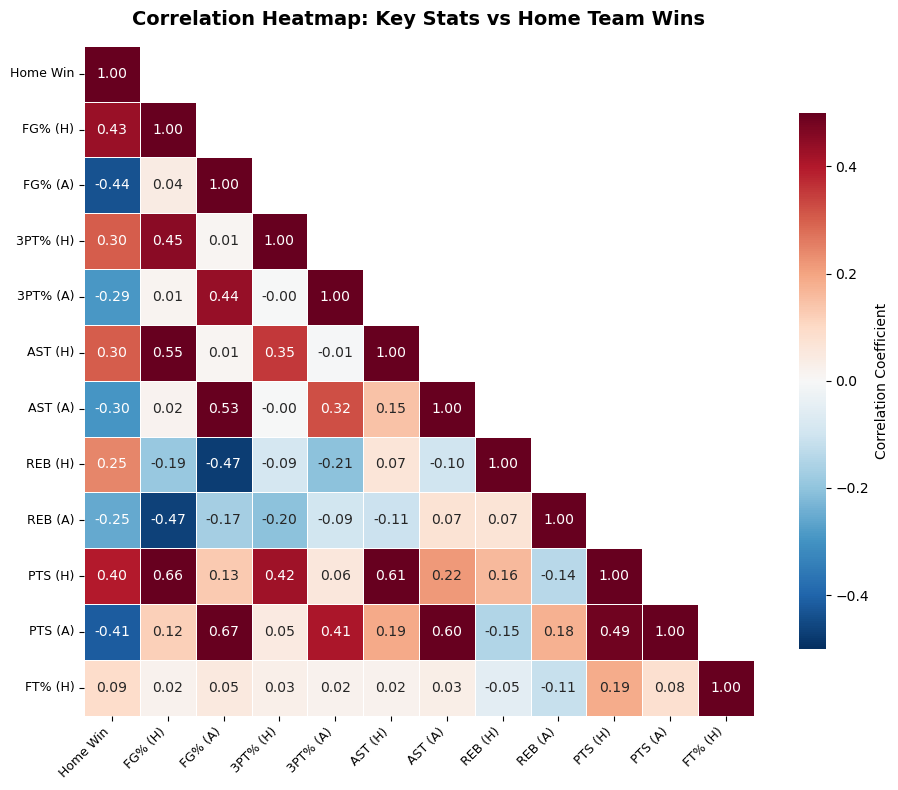

Saved: charts/slide3_correlation_heatmap.png


In [5]:
# correlation heatmap of key stats vs home wins
corr_cols = ['HOME_TEAM_WINS', 'FG_PCT_home', 'FG_PCT_away', 'FG3_PCT_home', 'FG3_PCT_away',
             'AST_home', 'AST_away', 'REB_home', 'REB_away', 'PTS_home', 'PTS_away', 'FT_PCT_home']
corr_labels = ['Home Win', 'FG% (H)', 'FG% (A)', '3PT% (H)', '3PT% (A)',
               'AST (H)', 'AST (A)', 'REB (H)', 'REB (A)', 'PTS (H)', 'PTS (A)', 'FT% (H)']
corr_matrix = games[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-0.5, vmax=0.5, square=True, linewidths=0.5,
            xticklabels=corr_labels, yticklabels=corr_labels,
            cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'}, ax=ax)
ax.set_title('Correlation Heatmap: Key Stats vs Home Team Wins', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('charts/slide3_correlation_heatmap.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: charts/slide3_correlation_heatmap.png')

## Home Court Advantage

The first thing I wanted to check: does playing at home actually help? Turns out, yes. Home teams win about 58.9% of all games, which is almost 9 points above the 50% you'd expect if location didn't matter.

I also wanted to see if this has changed over time. The chart below tracks the home win rate season by season. You can see it was up around 63% in the mid-2000s but has gradually dropped toward 56% by the end of the dataset. Could be better travel conditions, load management strategies, or just the league getting more competitive on the road.

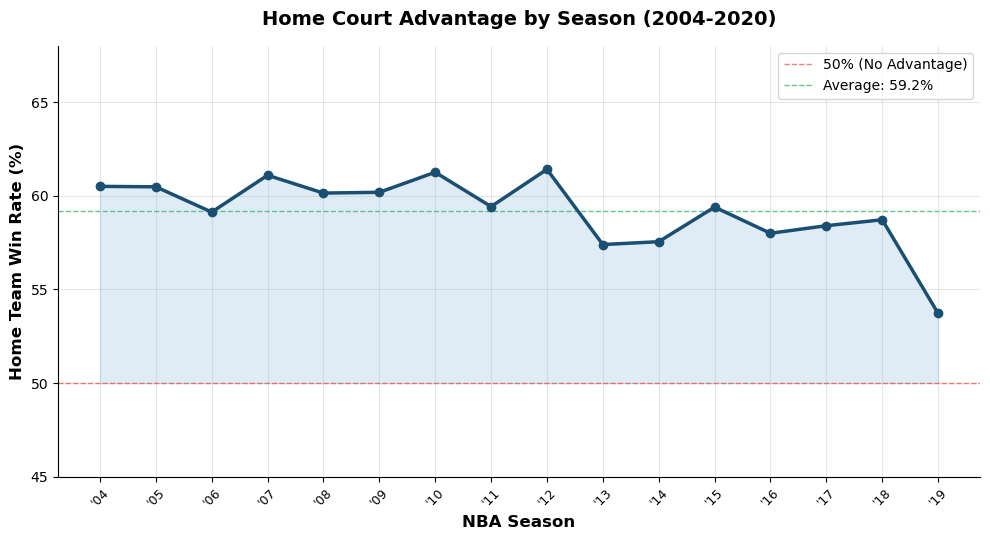

Saved: charts/slide2_home_court.png


In [6]:
# home win rate by season, line chart
season_wins = games.groupby('SEASON')['HOME_TEAM_WINS'].mean() * 100
season_wins = season_wins.sort_index()
season_wins = season_wins[(season_wins.index >= 2004) & (season_wins.index <= 2019)]

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(season_wins.index, season_wins.values, color='#1B4F72', linewidth=2.5,
        marker='o', markersize=6, zorder=3)
ax.fill_between(season_wins.index, 50, season_wins.values, alpha=0.15, color='#2E86C1')
ax.axhline(y=50, color='#E74C3C', linestyle='--', linewidth=1, alpha=0.7,
           label='50% (No Advantage)')
ax.axhline(y=season_wins.mean(), color='#27AE60', linestyle='--', linewidth=1, alpha=0.7,
           label=f'Average: {season_wins.mean():.1f}%')
ax.set_xlabel('NBA Season', fontsize=12, fontweight='bold')
ax.set_ylabel('Home Team Win Rate (%)', fontsize=12, fontweight='bold')
ax.set_title('Home Court Advantage by Season (2004-2020)', fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='upper right', fontsize=10)
ax.set_ylim(45, 68)
ax.set_xticks(season_wins.index)
ax.set_xticklabels([f"'{str(y)[2:]}" for y in season_wins.index], rotation=45, fontsize=9)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('charts/slide2_home_court.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: charts/slide2_home_court.png')

In [7]:
# which teams score the most at home? SQL query to check
sql = (
    "SELECT t.NICKNAME AS team, "
    "ROUND(AVG(g.PTS_home), 2) AS avg_home_pts, "
    "COUNT(*) AS games_played "
    "FROM games g "
    "JOIN teams t ON g.HOME_TEAM_ID = t.TEAM_ID "
    "WHERE g.PTS_home IS NOT NULL "
    "GROUP BY t.NICKNAME "
    "ORDER BY avg_home_pts DESC "
    "LIMIT 10"
)
query(sql)

,team,avg_home_pts,games_played
0,Warriors,109.54,904
1,Nuggets,108.63,871
2,Suns,107.71,888
3,Kings,105.31,837
4,Thunder,105.26,891
5,Mavericks,104.96,904
6,Rockets,104.73,896
7,Lakers,104.46,961
8,Raptors,104.15,888
9,Bucks,104.09,880


## Offense Stats: What Separates Winners from Losers

Beyond just shooting percentage, I wanted to compare the actual offensive numbers between winning and losing home teams. The grouped bar chart below breaks down points, assists, and rebounds for four groups: the home team when they win, the away team in those same games, the home team when they lose, and the away team in those games.

The differences are pretty clear. Winning home teams average around 107 points while losing home teams average closer to 98. Assists tell a similar story, and rebounds show about a 3-rebound swing between wins and losses. These stats are all connected though: teams that move the ball well (assists) tend to get better shots (higher FG%), score more points, and the cycle feeds itself.

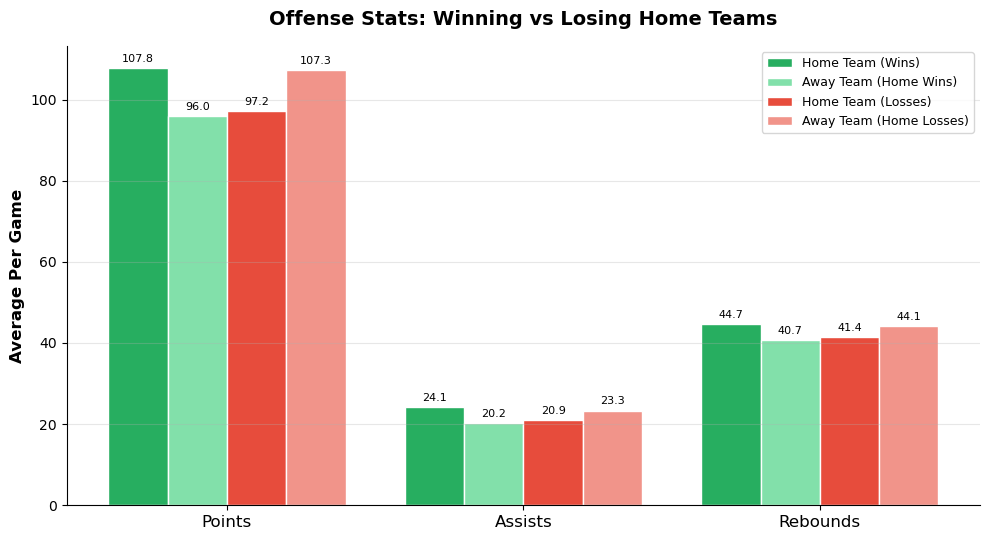

Saved: charts/slide4_offense_stats.png


In [8]:
# grouped bar chart comparing offense stats: wins vs losses
wins = games[games['HOME_TEAM_WINS'] == 1]
losses = games[games['HOME_TEAM_WINS'] == 0]

categories = ['Points', 'Assists', 'Rebounds']
win_vals = [wins['PTS_home'].mean(), wins['AST_home'].mean(), wins['REB_home'].mean()]
loss_vals = [losses['PTS_home'].mean(), losses['AST_home'].mean(), losses['REB_home'].mean()]
opp_win_vals = [wins['PTS_away'].mean(), wins['AST_away'].mean(), wins['REB_away'].mean()]
opp_loss_vals = [losses['PTS_away'].mean(), losses['AST_away'].mean(), losses['REB_away'].mean()]

x = np.arange(len(categories))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 5.5))
bars1 = ax.bar(x - 1.5*width, win_vals, width, label='Home Team (Wins)', color='#27AE60', edgecolor='white')
bars2 = ax.bar(x - 0.5*width, opp_win_vals, width, label='Away Team (Home Wins)', color='#82E0AA', edgecolor='white')
bars3 = ax.bar(x + 0.5*width, loss_vals, width, label='Home Team (Losses)', color='#E74C3C', edgecolor='white')
bars4 = ax.bar(x + 1.5*width, opp_loss_vals, width, label='Away Team (Home Losses)', color='#F1948A', edgecolor='white')

ax.set_ylabel('Average Per Game', fontsize=12, fontweight='bold')
ax.set_title('Offense Stats: Winning vs Losing Home Teams', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=12)
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3, axis='y')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# add value labels on top of each bar
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.1f}', xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('charts/slide4_offense_stats.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: charts/slide4_offense_stats.png')

In [9]:
# SQL breakdown of avg stats for home wins vs home losses
sql = (
    "SELECT HOME_TEAM_WINS, "
    "ROUND(AVG(PTS_home),1) AS avg_pts_home, ROUND(AVG(PTS_away),1) AS avg_pts_away, "
    "ROUND(AVG(AST_home),1) AS avg_ast_home, ROUND(AVG(AST_away),1) AS avg_ast_away, "
    "ROUND(AVG(REB_home),1) AS avg_reb_home, ROUND(AVG(REB_away),1) AS avg_reb_away "
    "FROM games WHERE HOME_TEAM_WINS IS NOT NULL AND PTS_home IS NOT NULL "
    "GROUP BY HOME_TEAM_WINS"
)
query(sql)

,HOME_TEAM_WINS,avg_pts_home,avg_pts_away,avg_ast_home,avg_ast_away,avg_reb_home,avg_reb_away
0,0,97.2,107.3,20.9,23.3,41.4,44.1
1,1,107.8,96.0,24.1,20.2,44.7,40.7


## Score Margins: Blowouts vs Close Games

Not every win looks the same. I wanted to see how score margins break down and whether home court advantage matters more in tight games.

When the home team wins, the average margin is about +9.1 points. When they lose, the average deficit is around -8.6. But the interesting part is looking at how home court advantage changes based on how close the game is. In blowouts (20+ point margin), home teams win about 59% of the time. In close games (5 points or less), that number drops to around 54%. So the home court edge seems to matter most when games are tight and the crowd and familiarity can actually make a difference.

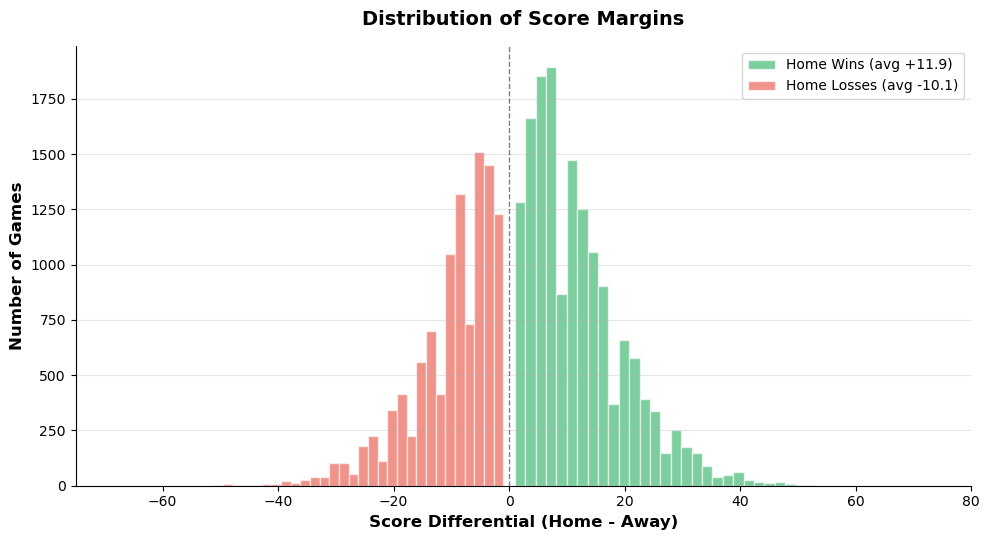

Saved: charts/slide5_score_distribution.png


In [10]:
# histogram of score differentials for home wins vs losses
fig, ax = plt.subplots(figsize=(10, 5.5))

wins_diff = games[games['HOME_TEAM_WINS'] == 1]['SCORE_DIFF']
losses_diff = games[games['HOME_TEAM_WINS'] == 0]['SCORE_DIFF']

ax.hist(wins_diff, bins=40, alpha=0.6, color='#27AE60', label=f'Home Wins (avg +{wins_diff.mean():.1f})', edgecolor='white')
ax.hist(losses_diff, bins=40, alpha=0.6, color='#E74C3C', label=f'Home Losses (avg {losses_diff.mean():.1f})', edgecolor='white')
ax.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('Score Differential (Home - Away)', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Games', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Score Margins', fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('charts/slide5_score_distribution.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: charts/slide5_score_distribution.png')

## Team-Level Breakdown: FG% and Win Rates

The correlation between FG% and winning shows up at the game level, but does it hold when you zoom out to the team level? The scatter plot below has each team plotted by their average home FG% on the x-axis and their home win rate on the y-axis.

The Warriors stand out at the top with both the highest FG% (.466) and the best home win rate around 73%, mostly driven by those dynasty years from 2014-2019. The Spurs are up there too with really consistent numbers across the whole dataset. On the other end, expansion-era teams like the Bobcats/Hornets and the Nets show lower FG% and lower win rates, which lines up with what we'd expect.

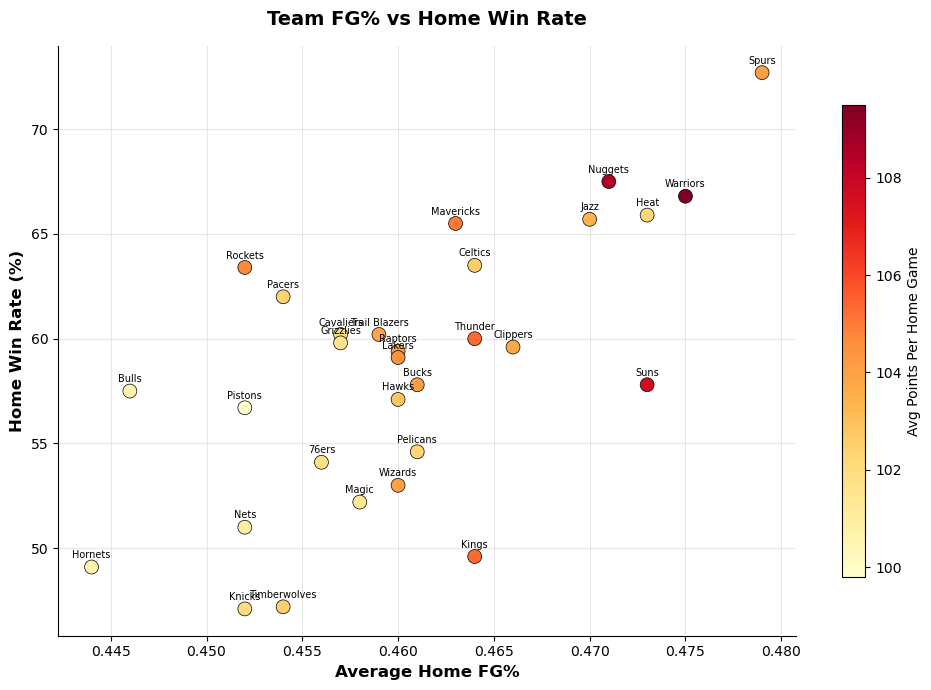

Saved: charts/slide6_team_scatter.png


In [11]:
# team-level scatter: FG% vs home win rate
sql = (
    "SELECT t.NICKNAME AS team, "
    "COUNT(*) AS home_games, "
    "ROUND(100.0*SUM(g.HOME_TEAM_WINS)/COUNT(*), 1) AS home_win_pct, "
    "ROUND(AVG(g.FG_PCT_home),3) AS avg_fg_pct, "
    "ROUND(AVG(g.PTS_home),1) AS avg_pts "
    "FROM games g JOIN teams t ON g.HOME_TEAM_ID = t.TEAM_ID "
    "WHERE g.HOME_TEAM_WINS IS NOT NULL "
    "GROUP BY t.NICKNAME "
    "ORDER BY home_win_pct DESC"
)
team_stats = query(sql)

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(team_stats['avg_fg_pct'], team_stats['home_win_pct'],
                c=team_stats['avg_pts'], cmap='YlOrRd', s=100, edgecolors='black', linewidth=0.5, zorder=3)

# label each point with team name
for _, row in team_stats.iterrows():
    ax.annotate(row['team'], (row['avg_fg_pct'], row['home_win_pct']),
                fontsize=7, ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

cbar = plt.colorbar(sc, ax=ax, shrink=0.8)
cbar.set_label('Avg Points Per Home Game', fontsize=10)
ax.set_xlabel('Average Home FG%', fontsize=12, fontweight='bold')
ax.set_ylabel('Home Win Rate (%)', fontsize=12, fontweight='bold')
ax.set_title('Team FG% vs Home Win Rate', fontsize=14, fontweight='bold', pad=15)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('charts/slide6_team_scatter.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: charts/slide6_team_scatter.png')

In [12]:
sql = (
    "SELECT t.NICKNAME AS team, "
    "COUNT(*) AS home_games, "
    "ROUND(100.0*SUM(g.HOME_TEAM_WINS)/COUNT(*), 1) AS home_win_pct, "
    "ROUND(AVG(g.FG_PCT_home),3) AS avg_fg_pct, "
    "ROUND(AVG(g.FG3_PCT_home),3) AS avg_fg3_pct, "
    "ROUND(AVG(g.PTS_home),1) AS avg_pts, "
    "ROUND(AVG(g.AST_home),1) AS avg_ast "
    "FROM games g JOIN teams t ON g.HOME_TEAM_ID = t.TEAM_ID "
    "WHERE g.HOME_TEAM_WINS IS NOT NULL "
    "GROUP BY t.NICKNAME "
    "ORDER BY home_win_pct DESC"
)
query(sql)

,team,home_games,home_win_pct,avg_fg_pct,avg_fg3_pct,avg_pts,avg_ast
0,Spurs,942,72.7,0.479,0.387,104.1,24.0
1,Nuggets,873,67.5,0.471,0.352,108.6,25.6
2,Warriors,907,66.8,0.475,0.375,109.5,26.2
3,Heat,959,65.9,0.473,0.357,102.2,21.0
4,Jazz,874,65.7,0.470,0.361,103.4,22.6
5,Mavericks,907,65.5,0.463,0.363,105.0,22.2
6,Celtics,950,63.5,0.464,0.356,102.6,23.7
7,Rockets,900,63.4,0.452,0.351,104.7,22.1
8,Pacers,891,62.0,0.454,0.356,102.4,22.0
9,Trail Blazers,871,60.2,0.459,0.365,103.9,21.8


## The Winning Profile: Stat Differentials

To pull everything together, here's a comparison of how the key stat differentials (home minus away) look in wins vs losses. The radar-style bar chart below makes the pattern pretty obvious: in wins, the home team leads across the board. In losses, every single metric flips negative.

The FG% differential is probably the most telling. In home wins, the home team shoots about 4.4% better than the opponent. In home losses, they shoot about 4.5% worse. That's nearly a 9 percentage point swing, and it shows up consistently across the whole dataset.

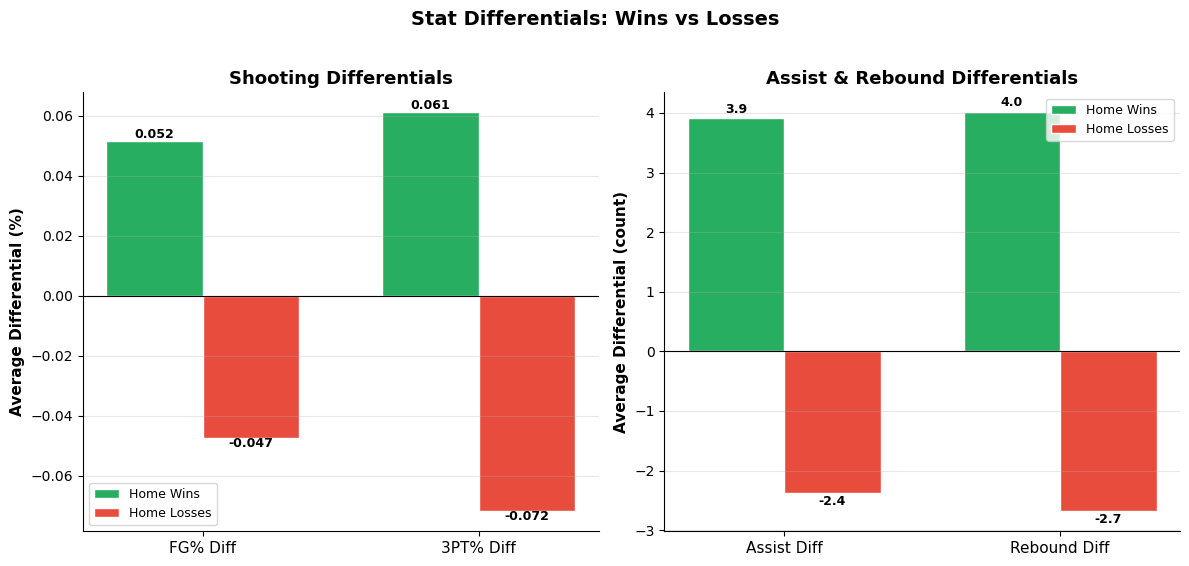

Saved: charts/slide7_differentials.png


In [13]:
# comparing stat differentials in wins vs losses
wins = games[games['HOME_TEAM_WINS'] == 1]
losses = games[games['HOME_TEAM_WINS'] == 0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.5))

# LEFT PLOT: percentage-based stats (small decimal values)
pct_stats = ['FG_PCT_DIFF', 'FG3_PCT_DIFF']
pct_labels = ['FG% Diff', '3PT% Diff']
pct_win = [wins[s].mean() for s in pct_stats]
pct_loss = [losses[s].mean() for s in pct_stats]

x1 = np.arange(len(pct_labels))
width = 0.35
ax1.bar(x1 - width/2, pct_win, width, label='Home Wins', color='#27AE60', edgecolor='white')
ax1.bar(x1 + width/2, pct_loss, width, label='Home Losses', color='#E74C3C', edgecolor='white')
ax1.set_ylabel('Average Differential (%)', fontsize=11, fontweight='bold')
ax1.set_title('Shooting Differentials', fontsize=13, fontweight='bold')
ax1.set_xticks(x1)
ax1.set_xticklabels(pct_labels, fontsize=11)
ax1.legend(fontsize=9)
ax1.axhline(y=0, color='black', linewidth=0.8)
ax1.grid(True, alpha=0.3, axis='y')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# add value labels
for i, (w, l) in enumerate(zip(pct_win, pct_loss)):
    ax1.text(i - width/2, w + 0.001 if w > 0 else w - 0.003, f'{w:.3f}', ha='center', fontsize=9, fontweight='bold')
    ax1.text(i + width/2, l - 0.003 if l < 0 else l + 0.001, f'{l:.3f}', ha='center', fontsize=9, fontweight='bold')

# RIGHT PLOT: counting stats (whole numbers)
cnt_stats = ['AST_DIFF', 'REB_DIFF']
cnt_labels = ['Assist Diff', 'Rebound Diff']
cnt_win = [wins[s].mean() for s in cnt_stats]
cnt_loss = [losses[s].mean() for s in cnt_stats]

x2 = np.arange(len(cnt_labels))
ax2.bar(x2 - width/2, cnt_win, width, label='Home Wins', color='#27AE60', edgecolor='white')
ax2.bar(x2 + width/2, cnt_loss, width, label='Home Losses', color='#E74C3C', edgecolor='white')
ax2.set_ylabel('Average Differential (count)', fontsize=11, fontweight='bold')
ax2.set_title('Assist & Rebound Differentials', fontsize=13, fontweight='bold')
ax2.set_xticks(x2)
ax2.set_xticklabels(cnt_labels, fontsize=11)
ax2.legend(fontsize=9)
ax2.axhline(y=0, color='black', linewidth=0.8)
ax2.grid(True, alpha=0.3, axis='y')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# add value labels
for i, (w, l) in enumerate(zip(cnt_win, cnt_loss)):
    ax2.text(i - width/2, w + 0.1, f'{w:.1f}', ha='center', fontsize=9, fontweight='bold')
    ax2.text(i + width/2, l - 0.2, f'{l:.1f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Stat Differentials: Wins vs Losses', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('charts/slide7_differentials.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: charts/slide7_differentials.png')

## How Each Stat Shifts Win Probability

The last thing I wanted to look at is how each stat differential actually translates to win probability. For each chart below, the x-axis is the differential (positive means the home team leads in that stat) and the y-axis is the observed win rate for games in that bin.

All four stats show a really strong linear relationship. When the home team shoots just 5% better from the field than the opponent, their win probability jumps to around 75%. A +5 assist advantage or +5 rebound advantage both translate to roughly 70% win rates. These are the levers that coaches and teams can actually pull to improve their chances.

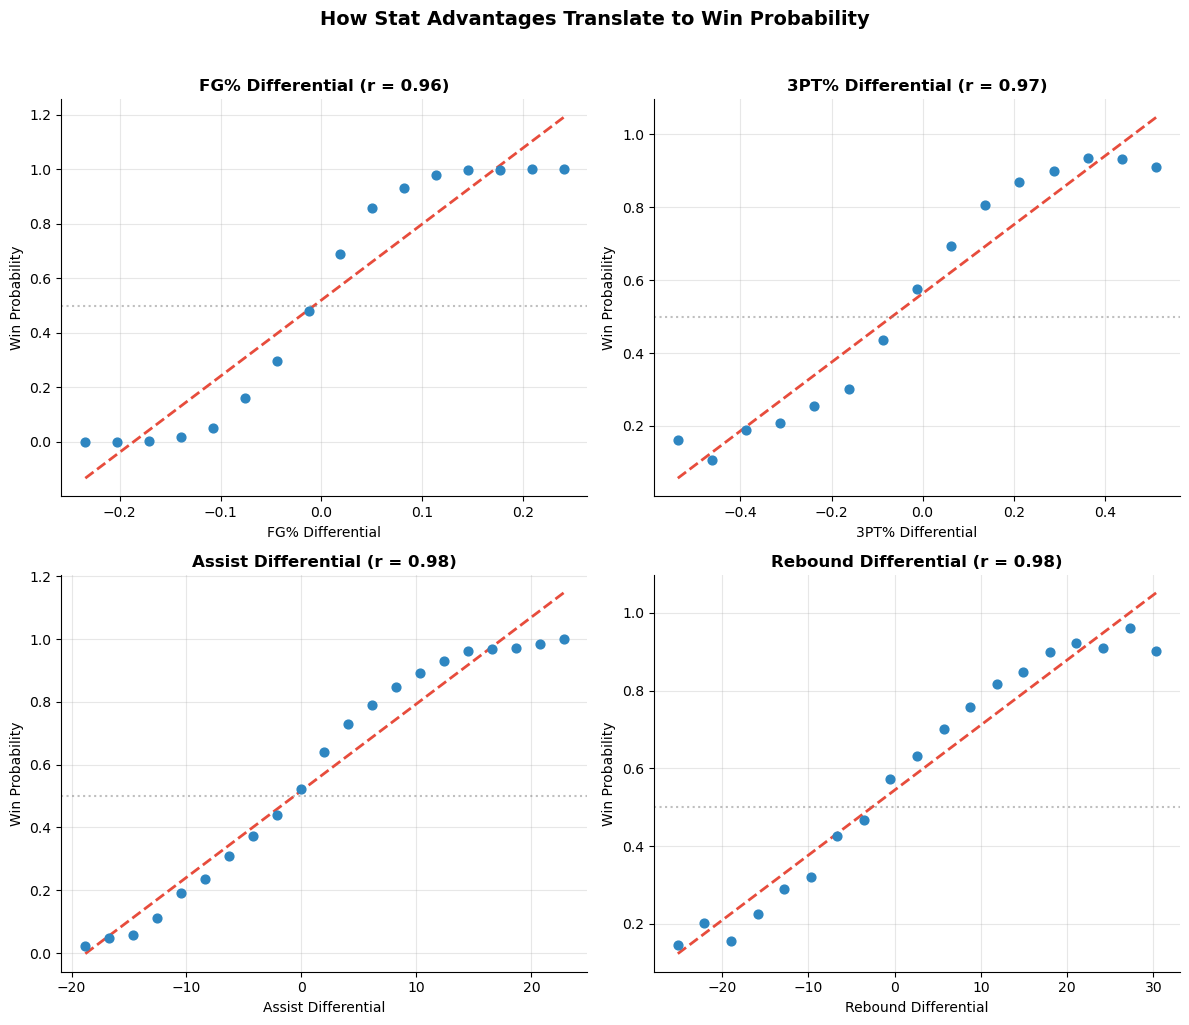

Saved: charts/slide8_win_probability.png


In [14]:
# win probability vs stat differentials, 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

diff_stats = [
    ('FG_PCT_DIFF', 'FG% Differential', 20),
    ('FG3_PCT_DIFF', '3PT% Differential', 20),
    ('AST_DIFF', 'Assist Differential', 25),
    ('REB_DIFF', 'Rebound Differential', 25)
]

for idx, (col, title, nbins) in enumerate(diff_stats):
    ax = axes[idx // 2][idx % 2]
    
    # bin the differential and calc win rate per bin
    games['_bin'] = pd.cut(games[col], bins=nbins)
    binned = games.groupby('_bin')['HOME_TEAM_WINS'].agg(['mean', 'count'])
    binned = binned[binned['count'] >= 30]  # only keep bins with enough games
    bin_centers = [interval.mid for interval in binned.index]
    
    ax.scatter(bin_centers, binned['mean'], color='#2E86C1', s=40, zorder=3)
    
    # add trend line
    z = np.polyfit(bin_centers, binned['mean'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(min(bin_centers), max(bin_centers), 100)
    ax.plot(x_line, p(x_line), color='#E74C3C', linewidth=2, linestyle='--')
    
    # correlation
    r = np.corrcoef(bin_centers, binned['mean'])[0, 1]
    ax.set_title(f'{title} (r = {r:.2f})', fontsize=12, fontweight='bold')
    ax.set_xlabel(title, fontsize=10)
    ax.set_ylabel('Win Probability', fontsize=10)
    ax.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

games.drop('_bin', axis=1, inplace=True)
plt.suptitle('How Stat Advantages Translate to Win Probability', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('charts/slide8_win_probability.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: charts/slide8_win_probability.png')

## Insights

After going through all this data, here's what I found:

**Shooting efficiency is the single biggest factor in winning.** FG% has the highest correlation with wins at r=0.43, and the relationship holds at both the game level and the team level. Even a small 4-5% edge in FG% over the opponent pushes win probability up to around 70%.

**Home court advantage is real but shrinking.** Home teams win roughly 59% of games overall, but that number has come down from the low 60s in the mid-2000s to the mid-50s more recently. It still matters though, especially in close games where the margin between winning and losing is tiny.

**Ball movement matters a lot.** Assists have a strong positive correlation with winning (r=0.30), and it makes sense when you think about it. More assists usually means better shot selection, which means higher FG%, which means more points. It's all connected.

**Rebounds give you extra chances.** The rebound differential between wins and losses is about 6 boards. More rebounds means more possessions, and more possessions means more opportunities to score.

**Free throws are overrated as a win predictor.** This one surprised me. FT% has the weakest correlation with winning out of all the shooting stats at r=0.09. Games just aren't decided at the free throw line as often as people think.

**The winning formula is pretty consistent.** When you look at the stat differentials in wins vs losses, the pattern is symmetric. Every key stat flips from positive to negative. There's a clear profile of what a winning game looks like, and it comes down to shooting well, sharing the ball, and controlling the boards.

## Conclusion

This analysis covered 26,552 NBA games from 2004 to 2020. The data paints a pretty clear picture of what wins basketball games. Shooting efficiency (FG%) is the most important factor, followed by scoring output, ball movement (assists), three-point shooting, and rebounding. Home court advantage adds about a 9% boost to win probability but has been declining over the years.

If I were to dig deeper, some next steps would be looking at player-level data to see which individuals impact their team's FG% the most, checking whether these correlations have shifted as the league has moved toward more three-point shooting, and examining whether these patterns hold in clutch situations late in close games.